# EDA подготовленного MovieLens датасета

Ноутбук содержит базовый анализ датасета, полученного после предобработки, генерации дополнительных признаков и **сплита по времени**.

EDA преследует цели:

- проверить размеры всех сохранённых таблиц;
- посмотреть распределение рейтингов;
- оценить длины пользовательских историй;
- сравнить warm-start и cold-start части;
- проверить признаки фильмов и пропуски;
- убедиться, что разбиение не выглядит сломанным.

Ноутбук ничего не изменяет в датасете: он только загружает готовые `parquet` и `json` файлы и строит сводные таблицы/графики.


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

DEFAULT_DATA_DIR = "/kaggle/input/datasets/daniilzagatin/movielens20-withfeatures-split"
DATA_DIR = Path(os.environ.get("MOVIELENS_SPLIT_DIR", DEFAULT_DATA_DIR))
print("DATA_DIR exists:", DATA_DIR.exists())
print(DATA_DIR)


DATA_DIR exists: True
/kaggle/input/datasets/daniilzagatin/movielens20-withfeatures-split


## 1. Список файлов

Сначала проверяем, какие файлы лежат в директории с подготовленным датасетом.  
Это помогает быстро понять, все ли артефакты были сохранены после подготовки.


In [2]:

all_files = sorted(DATA_DIR.glob("*"))
print(f"Всего файлов: {len(all_files)}\n")

for p in all_files:
    size_mb = p.stat().st_size / (1024 ** 2)
    print(f"{p.name:40s} {size_mb:8.2f} MB")

Всего файлов: 22

all_item2idx.json                            0.56 MB
both_cold_test_interactions.parquet          0.13 MB
both_cold_val_interactions.parquet           0.08 MB
cold_item2idx.json                           0.01 MB
cold_item_test_interactions.parquet          1.15 MB
cold_item_val_interactions.parquet           0.76 MB
cold_user2idx.json                           0.27 MB
cold_user_support.parquet                   21.63 MB
cold_user_support_all.parquet               23.45 MB
cold_user_test_interactions.parquet          1.65 MB
cold_user_val_interactions.parquet           1.11 MB
feature_cols.json                            0.00 MB
item_features_all.parquet                    8.56 MB
item_features_warm.parquet                   8.14 MB
item_meta.parquet                            0.78 MB
split_config.json                            0.00 MB
train_warm_interactions.parquet            192.71 MB
user_meta.parquet                            7.03 MB
warm_item2idx.json          

## 2. Хелперы загрузки

Небольшие функции для безопасной загрузки `parquet` и `json` файлов.  
Если какого-то файла нет, ноутбук не падает сразу, а явно показывает пропуск.


In [3]:

def load_parquet_if_exists(path: Path):
    if path.exists():
        df = pd.read_parquet(path)
        print(f"Loaded: {path.name:40s} shape={df.shape}")
        return df
    print(f"Missing: {path.name}")
    return None

def load_json_if_exists(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            obj = json.load(f)
        print(f"Loaded: {path.name}")
        return obj
    print(f"Missing: {path.name}")
    return None

## 3. Загрузка основных таблиц

Загружаются interaction-таблицы, support-история cold-пользователей, признаки фильмов и служебные meta-таблицы.


In [4]:

train = load_parquet_if_exists(DATA_DIR / "train_warm_interactions.parquet")

warm_val = load_parquet_if_exists(DATA_DIR / "warm_val_interactions.parquet")
warm_test = load_parquet_if_exists(DATA_DIR / "warm_test_interactions.parquet")

cold_user_support = load_parquet_if_exists(DATA_DIR / "cold_user_support.parquet")
cold_user_support_all = load_parquet_if_exists(DATA_DIR / "cold_user_support_all.parquet")
cold_user_val = load_parquet_if_exists(DATA_DIR / "cold_user_val_interactions.parquet")
cold_user_test = load_parquet_if_exists(DATA_DIR / "cold_user_test_interactions.parquet")

cold_item_val = load_parquet_if_exists(DATA_DIR / "cold_item_val_interactions.parquet")
cold_item_test = load_parquet_if_exists(DATA_DIR / "cold_item_test_interactions.parquet")

both_cold_val = load_parquet_if_exists(DATA_DIR / "both_cold_val_interactions.parquet")
both_cold_test = load_parquet_if_exists(DATA_DIR / "both_cold_test_interactions.parquet")

item_features_all = load_parquet_if_exists(DATA_DIR / "item_features_all.parquet")
item_features_warm = load_parquet_if_exists(DATA_DIR / "item_features_warm.parquet")
user_meta = load_parquet_if_exists(DATA_DIR / "user_meta.parquet")
item_meta = load_parquet_if_exists(DATA_DIR / "item_meta.parquet")

feature_cols = load_json_if_exists(DATA_DIR / "feature_cols.json")
split_config = load_json_if_exists(DATA_DIR / "split_config.json")

Loaded: train_warm_interactions.parquet          shape=(19574307, 7)
Loaded: warm_val_interactions.parquet            shape=(604994, 7)
Loaded: warm_test_interactions.parquet           shape=(987722, 7)
Loaded: cold_user_support.parquet                shape=(2170334, 7)
Loaded: cold_user_support_all.parquet            shape=(2295457, 8)
Loaded: cold_user_val_interactions.parquet       shape=(66243, 7)
Loaded: cold_user_test_interactions.parquet      shape=(106919, 7)
Loaded: cold_item_val_interactions.parquet       shape=(35162, 7)
Loaded: cold_item_test_interactions.parquet      shape=(55411, 7)
Loaded: both_cold_val_interactions.parquet       shape=(3820, 7)
Loaded: both_cold_test_interactions.parquet      shape=(6060, 7)
Loaded: item_features_all.parquet                shape=(32720, 172)
Loaded: item_features_warm.parquet               shape=(31999, 172)
Loaded: user_meta.parquet                        shape=(159944, 27)
Loaded: item_meta.parquet                        shape=(32720,

## 4. Быстрая сводка по таблицам

Смотрим размеры таблиц и число уникальных пользователей, фильмов и рейтингов.  
Это первая проверка того, что датасет собран ожидаемым образом.


In [5]:

tables = {
    "train_warm": train,
    "warm_val": warm_val,
    "warm_test": warm_test,
    "cold_user_support": cold_user_support,
    "cold_user_support_all": cold_user_support_all,
    "cold_user_val": cold_user_val,
    "cold_user_test": cold_user_test,
    "cold_item_val": cold_item_val,
    "cold_item_test": cold_item_test,
    "both_cold_val": both_cold_val,
    "both_cold_test": both_cold_test,
    "item_features_all": item_features_all,
    "item_features_warm": item_features_warm,
    "user_meta": user_meta,
    "item_meta": item_meta,
}

summary_rows = []
for name, df in tables.items():
    if df is not None:
        row = {
            "table": name,
            "rows": len(df),
            "cols": df.shape[1],
        }
        if "userId" in df.columns:
            row["n_users"] = df["userId"].nunique()
        if "movieId" in df.columns:
            row["n_items"] = df["movieId"].nunique()
        if "rating" in df.columns:
            row["rating_mean"] = df["rating"].mean()
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("table").reset_index(drop=True)
display(summary_df)

,table,rows,cols,n_users,n_items,rating_mean
0,both_cold_test,6060,7,4572.0,468.0,3.421617
1,both_cold_val,3820,7,3173.0,352.0,3.515445
2,cold_item_test,55411,7,41398.0,703.0,3.401743
3,cold_item_val,35162,7,29105.0,650.0,3.500668
4,cold_user_support,2170334,7,15934.0,25741.0,3.549601
5,cold_user_support_all,2295457,8,15935.0,26458.0,3.554251
6,cold_user_test,106919,7,15934.0,10199.0,3.336806
7,cold_user_val,66243,7,15918.0,7839.0,3.437118
8,item_features_all,32720,172,NaN,32720.0,NaN
9,item_features_warm,31999,172,NaN,31999.0,NaN


## 5. Конфиг сплита

Файл `split_config.json` фиксирует основные параметры подготовки: seed, пороги, размер warm/cold частей и число признаков.


In [6]:

print("split_config:")
print(json.dumps(split_config, indent=2, ensure_ascii=False) if split_config is not None else "Нет файла split_config.json")

split_config:
{
  "seed": 42,
  "positive_threshold": 4.0,
  "n_val_pos": 2,
  "n_test_pos": 3,
  "min_pos_per_user_for_split": 6,
  "min_user_interactions_kcore": 5,
  "min_item_interactions_kcore": 5,
  "cold_user_holdout": 0.1,
  "cold_item_holdout": 0.05,
  "min_support_interactions_for_cold_user": 5,
  "min_support_positives_for_cold_user": 1,
  "min_item_total_interactions_for_cold": 20,
  "min_item_positive_interactions_for_cold": 10,
  "min_item_unique_users_for_cold": 10,
  "genome_svd_dim": 64,
  "person_topk_thresholds": [
    50,
    100,
    250,
    500
  ],
  "principal_categories": [
    "actor",
    "actress",
    "director",
    "writer"
  ],
  "n_users_total": 159944,
  "n_items_total": 32720,
  "n_users_warm": 144009,
  "n_users_cold": 15935,
  "n_items_warm": 31999,
  "n_items_cold": 721,
  "n_train_warm_interactions": 19574307,
  "n_warm_val_interactions": 604994,
  "n_warm_test_interactions": 987722,
  "n_cold_user_val_interactions": 66243,
  "n_cold_user_test_in

## 6. Распределение рейтингов по сплитам

Проверяем, как оценки распределены в train, validation, test и cold-срезах.  
Так как датасет хранит raw ratings, здесь должны присутствовать не только положительные оценки.


In [7]:

rating_tables = {
    "train_warm": train,
    "warm_val": warm_val,
    "warm_test": warm_test,
    "cold_user_support": cold_user_support_all if cold_user_support_all is not None else cold_user_support,
    "cold_user_val": cold_user_val,
    "cold_user_test": cold_user_test,
    "cold_item_val": cold_item_val,
    "cold_item_test": cold_item_test,
    "both_cold_val": both_cold_val,
    "both_cold_test": both_cold_test,
}

rating_dist = []
for name, df in rating_tables.items():
    if df is not None and "rating" in df.columns:
        vc = df["rating"].value_counts().sort_index()
        for rating, cnt in vc.items():
            rating_dist.append({"split": name, "rating": rating, "count": cnt})

rating_dist_df = pd.DataFrame(rating_dist)
display(rating_dist_df.head())

,split,rating,count
0,train_warm,0.5,293648
1,train_warm,1.0,585224
2,train_warm,1.5,306642
3,train_warm,2.0,1260668
4,train_warm,2.5,980947


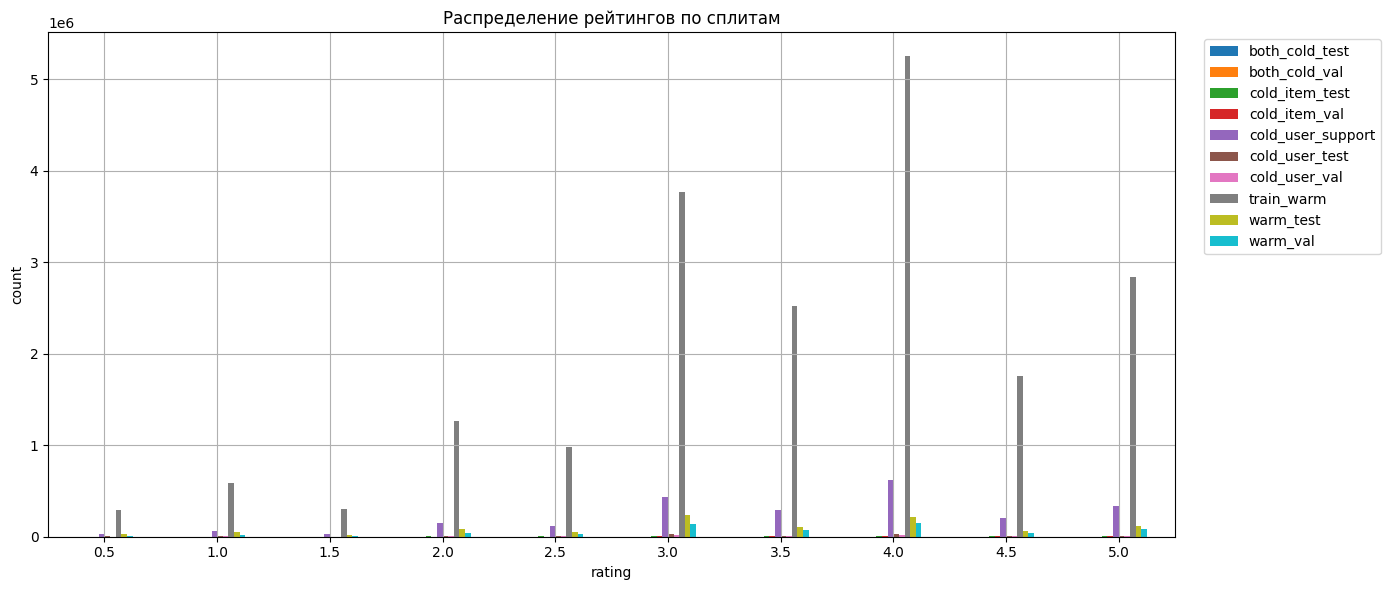

In [8]:

if not rating_dist_df.empty:
    pivot = rating_dist_df.pivot(index="rating", columns="split", values="count").fillna(0)
    pivot.plot(kind="bar", figsize=(14, 6))
    plt.title("Распределение рейтингов по сплитам")
    plt.xlabel("rating")
    plt.ylabel("count")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

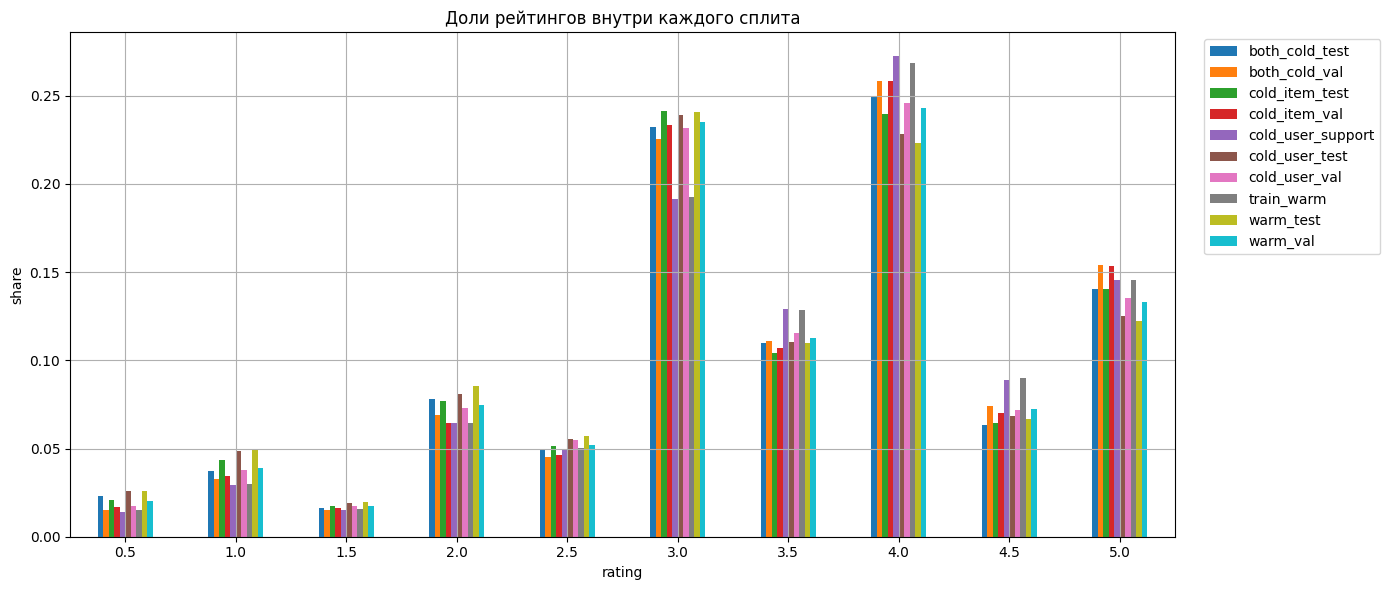

In [9]:

if not rating_dist_df.empty:
    share_df = rating_dist_df.copy()
    total_per_split = share_df.groupby("split")["count"].transform("sum")
    share_df["share"] = share_df["count"] / total_per_split

    pivot_share = share_df.pivot(index="rating", columns="split", values="share").fillna(0)
    pivot_share.plot(kind="bar", figsize=(14, 6))
    plt.title("Доли рейтингов внутри каждого сплита")
    plt.xlabel("rating")
    plt.ylabel("share")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 7. Длины историй пользователей в train

Анализируем, сколько взаимодействий есть у пользователей в обучающей части.  
Это важно для моделей, которые строят представление пользователя по истории.


count    144009.000000
mean        135.924192
std         245.079568
min           1.000000
50%          58.000000
75%         143.000000
90%         322.000000
95%         512.000000
99%        1138.000000
max       21687.000000
Name: n_interactions, dtype: float64


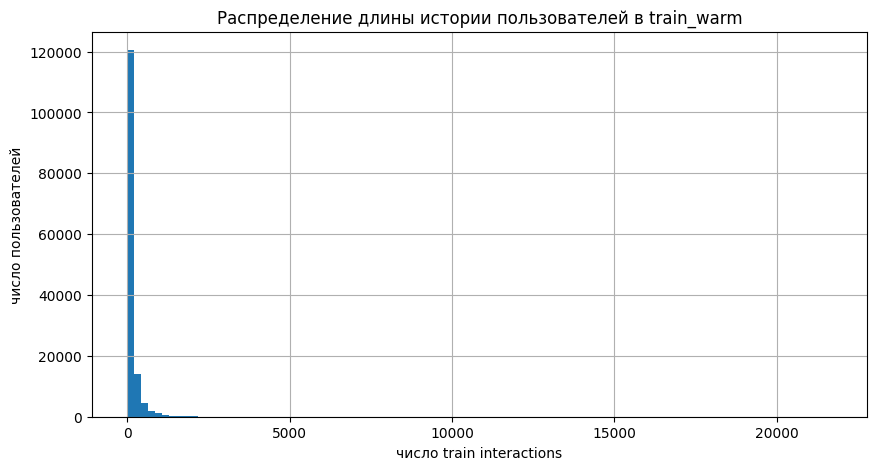

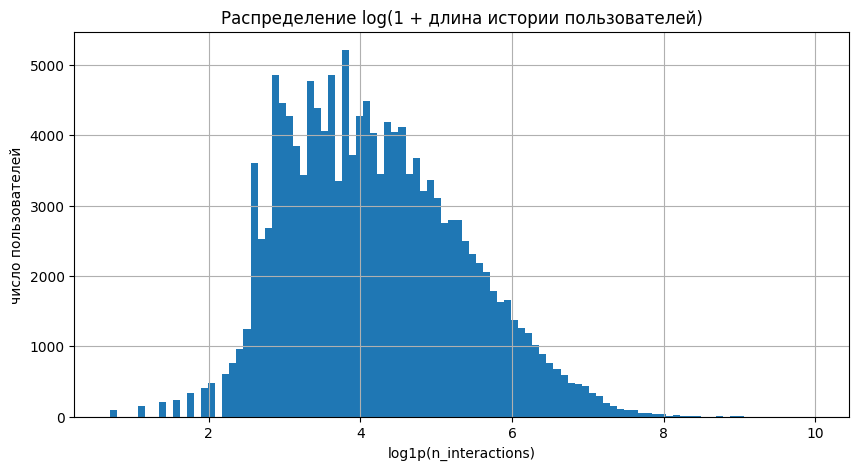

In [10]:

if train is not None:
    user_hist = train.groupby("userId").size().rename("n_interactions").reset_index()

    print(user_hist["n_interactions"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

    plt.figure(figsize=(10, 5))
    plt.hist(user_hist["n_interactions"], bins=100)
    plt.title("Распределение длины истории пользователей в train_warm")
    plt.xlabel("число train interactions")
    plt.ylabel("число пользователей")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(np.log1p(user_hist["n_interactions"]), bins=100)
    plt.title("Распределение log(1 + длина истории пользователей)")
    plt.xlabel("log1p(n_interactions)")
    plt.ylabel("число пользователей")
    plt.show()

## 8. Популярность фильмов в train

Проверяем распределение числа взаимодействий по фильмам.  
Для рекомендательных систем обычно характерен длинный хвост: часть фильмов очень популярна, а большинство встречается редко.


count    31999.000000
mean       611.716210
std       2678.928579
min          1.000000
50%         21.000000
75%        144.000000
90%        997.000000
95%       2780.100000
99%      11880.260000
max      68688.000000
Name: n_interactions, dtype: float64


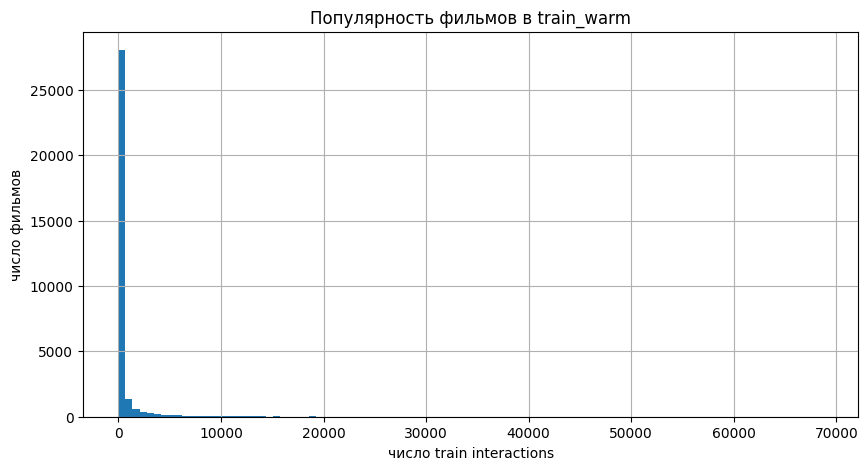

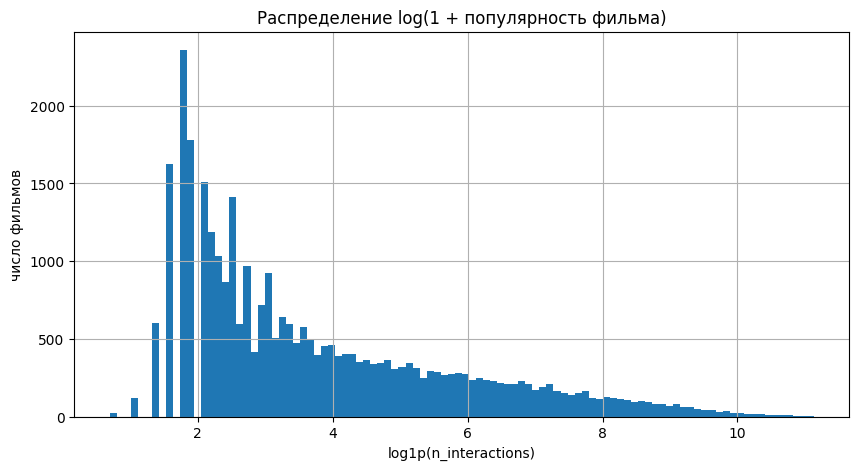

In [11]:

if train is not None:
    item_pop = train.groupby("movieId").size().rename("n_interactions").reset_index()

    print(item_pop["n_interactions"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

    plt.figure(figsize=(10, 5))
    plt.hist(item_pop["n_interactions"], bins=100)
    plt.title("Популярность фильмов в train_warm")
    plt.xlabel("число train interactions")
    plt.ylabel("число фильмов")
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.hist(np.log1p(item_pop["n_interactions"]), bins=100)
    plt.title("Распределение log(1 + популярность фильма)")
    plt.xlabel("log1p(n_interactions)")
    plt.ylabel("число фильмов")
    plt.show()

## 9. Проверка cold-user / cold-item логики

Проверяем, что cold-пользователи и cold-фильмы действительно отделены от warm train там, где это требуется.


In [12]:

def unique_vals(df, col):
    if df is None or col not in df.columns:
        return set()
    return set(df[col].unique())

warm_users = unique_vals(train, "userId")
warm_items = unique_vals(train, "movieId")

cold_user_eval_users = unique_vals(cold_user_val, "userId") | unique_vals(cold_user_test, "userId")
cold_item_eval_items = unique_vals(cold_item_val, "movieId") | unique_vals(cold_item_test, "movieId")

print("Warm users in train:", len(warm_users))
print("Warm items in train:", len(warm_items))
print("Cold-user eval users:", len(cold_user_eval_users))
print("Cold-item eval items:", len(cold_item_eval_items))

print("\nПересечение cold_user_eval_users с warm_users:", len(cold_user_eval_users & warm_users))
print("Пересечение cold_item_eval_items с warm_items:", len(cold_item_eval_items & warm_items))

Warm users in train: 144009
Warm items in train: 31999
Cold-user eval users: 15935
Cold-item eval items: 721

Пересечение cold_user_eval_users с warm_users: 0
Пересечение cold_item_eval_items с warm_items: 0


## 10. Размеры interaction-сплитов

Сравниваем размеры train/support, validation и test частей для разных сценариев оценки.


In [13]:

plot_rows = []
for name, df in tables.items():
    if df is not None and "rating" in df.columns:
        plot_rows.append({"split": name, "rows": len(df)})

plot_df = pd.DataFrame(plot_rows).sort_values("rows", ascending=False)
display(plot_df)

,split,rows
0,train_warm,19574307
4,cold_user_support_all,2295457
3,cold_user_support,2170334
2,warm_test,987722
1,warm_val,604994
6,cold_user_test,106919
5,cold_user_val,66243
8,cold_item_test,55411
7,cold_item_val,35162
10,both_cold_test,6060


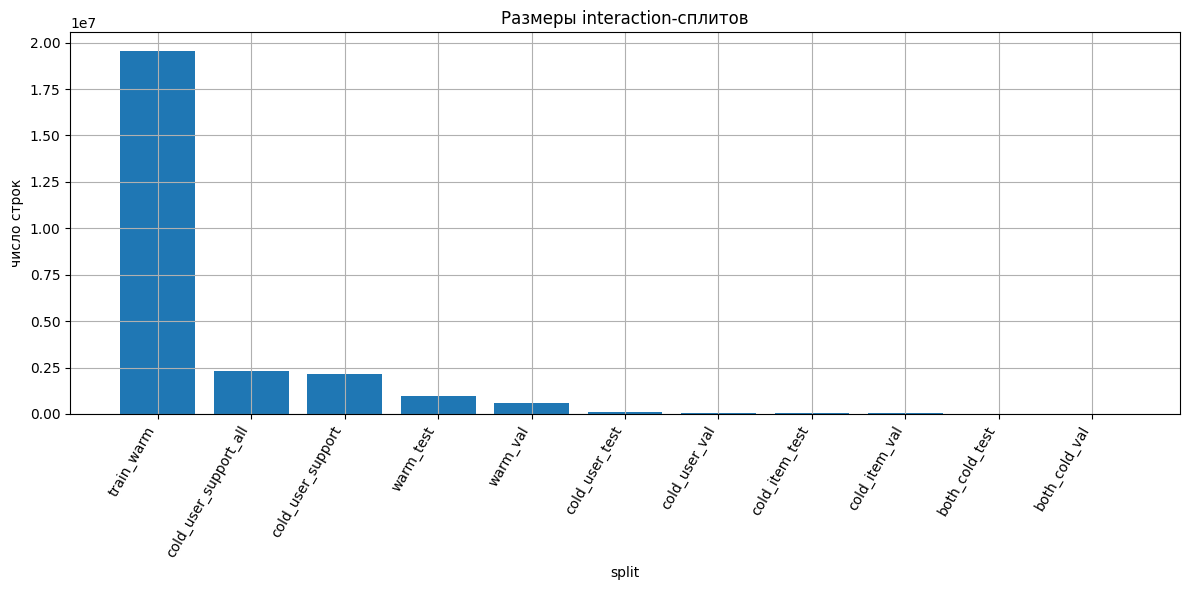

In [14]:

if not plot_df.empty:
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["split"], plot_df["rows"])
    plt.title("Размеры interaction-сплитов")
    plt.xlabel("split")
    plt.ylabel("число строк")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

## 11. Временной диапазон сплитов

Проверяем диапазоны timestamp в разных частях датасета.  
Это дополнительная sanity-check проверка для сплита по времени.


In [15]:

time_rows = []

for name, df in tables.items():
    if df is not None and "timestamp" in df.columns:
        ts = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")
        time_rows.append({
            "split": name,
            "min_time": ts.min(),
            "max_time": ts.max(),
            "n_rows": len(df),
        })

time_df = pd.DataFrame(time_rows).sort_values("split").reset_index(drop=True)
display(time_df)

,split,min_time,max_time,n_rows
0,both_cold_test,1996-03-01 00:00:00,2019-11-19 17:17:41,6060
1,both_cold_val,1996-03-01 00:00:00,2019-11-18 15:06:49,3820
2,cold_item_test,1996-02-23 12:55:59,2019-11-21 08:11:12,55411
3,cold_item_val,1996-02-28 07:14:40,2019-11-21 03:14:32,35162
4,cold_user_support,1996-02-20 16:56:50,2019-11-20 08:35:05,2170334
5,cold_user_support_all,1996-02-20 16:56:50,2019-11-20 08:35:05,2295457
6,cold_user_test,1996-03-01 00:00:00,2019-11-21 06:30:40,106919
7,cold_user_val,1996-03-01 00:00:00,2019-11-21 06:16:48,66243
8,train_warm,1995-01-09 11:46:49,2019-11-21 09:09:59,19574307
9,warm_test,1996-02-02 12:36:59,2019-11-21 09:15:03,987722


## 12. Обзор item features

Смотрим размер таблиц признаков фильмов и базовые свойства feature space.


In [16]:

if item_features_all is not None:
    print("shape:", item_features_all.shape)
    print("\nПервые колонки:")
    print(item_features_all.columns[:50].tolist())

    if feature_cols is not None:
        print("\nЧисло feature_cols:", len(feature_cols))
        missing_from_df = [c for c in feature_cols if c not in item_features_all.columns]
        print("feature_cols отсутствуют в item_features_all:", len(missing_from_df))
        if missing_from_df[:20]:
            print("Примеры:", missing_from_df[:20])

shape: (32720, 172)

Первые колонки:
['movieId', 'title', 'year', 'year_missing', 'decade', 'imdbId', 'tmdbId', 'genre_count', 'genre__action', 'genre__adventure', 'genre__animation', 'genre__children', 'genre__comedy', 'genre__crime', 'genre__documentary', 'genre__drama', 'genre__fantasy', 'genre__film_noir', 'genre__horror', 'genre__imax', 'genre__musical', 'genre__mystery', 'genre__no_genres_listed', 'genre__romance', 'genre__sci_fi', 'genre__thriller', 'genre__war', 'genre__western', 'genome_missing', 'genome_svd_000', 'genome_svd_001', 'genome_svd_002', 'genome_svd_003', 'genome_svd_004', 'genome_svd_005', 'genome_svd_006', 'genome_svd_007', 'genome_svd_008', 'genome_svd_009', 'genome_svd_010', 'genome_svd_011', 'genome_svd_012', 'genome_svd_013', 'genome_svd_014', 'genome_svd_015', 'genome_svd_016', 'genome_svd_017', 'genome_svd_018', 'genome_svd_019', 'genome_svd_020']

Число feature_cols: 160
feature_cols отсутствуют в item_features_all: 0


## 13. Группы признаков по префиксам

Быстрая группировка колонок помогает понять, из каких источников состоит итоговый набор признаков.


In [17]:

if item_features_all is not None:
    cols = item_features_all.columns.tolist()

    groups = {
        "genre__": [c for c in cols if c.startswith("genre__")],
        "genome_svd_": [c for c in cols if c.startswith("genome_svd_")],
        "imdb_titleType_": [c for c in cols if c.startswith("imdb_titleType_")],
        "imdb_genre__": [c for c in cols if c.startswith("imdb_genre__")],
        "cast_top": [c for c in cols if c.startswith("cast_top")],
        "director_top": [c for c in cols if c.startswith("director_top")],
        "cast_popularity_": [c for c in cols if c.startswith("cast_popularity_")],
        "director_popularity_": [c for c in cols if c.startswith("director_popularity_")],
    }

    group_summary = pd.DataFrame([
        {"group": k, "n_cols": len(v), "example_cols": v[:5]}
        for k, v in groups.items()
    ])
    display(group_summary)

,group,n_cols,example_cols
0,genre__,20,"[genre__action, genre__adventure, genre__anima..."
1,genome_svd_,64,"[genome_svd_000, genome_svd_001, genome_svd_00..."
2,imdb_titleType_,9,"[imdb_titleType_movie, imdb_titleType_short, i..."
3,imdb_genre__,27,"[imdb_genre__action, imdb_genre__adult, imdb_g..."
4,cast_top,8,"[cast_top50_count, cast_top100_count, cast_top..."
5,director_top,8,"[director_top50_count, director_top100_count, ..."
6,cast_popularity_,3,"[cast_popularity_max, cast_popularity_mean, ca..."
7,director_popularity_,3,"[director_popularity_max, director_popularity_..."


## 14. Пропуски в item features

Проверяем долю пропусков в признаках фильмов.  
После подготовки большинство модельных числовых признаков должно быть заполнено.


Топ-30 колонок по missingness:


,column,missing_share
0,tmdbId,0.0011
1,movieId,0.0000
2,year,0.0000
3,title,0.0000
4,year_missing,0.0000
5,decade,0.0000
6,imdbId,0.0000
7,genre_count,0.0000
8,genre__action,0.0000
9,genre__adventure,0.0000


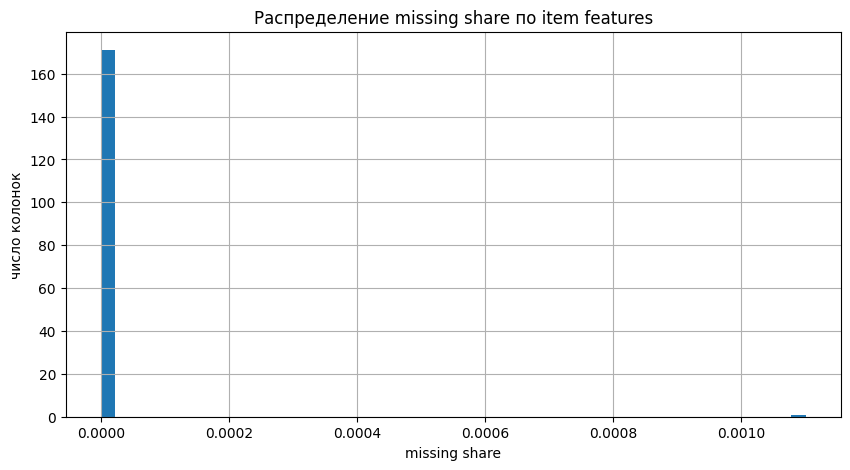

In [18]:

if item_features_all is not None:
    missing_share = item_features_all.isna().mean().sort_values(ascending=False)
    missing_df = missing_share.reset_index()
    missing_df.columns = ["column", "missing_share"]

    print("Топ-30 колонок по missingness:")
    display(missing_df.head(30))

    plt.figure(figsize=(10, 5))
    plt.hist(missing_df["missing_share"], bins=50)
    plt.title("Распределение missing share по item features")
    plt.xlabel("missing share")
    plt.ylabel("число колонок")
    plt.show()

## 15. Частоты жанров MovieLens

Смотрим, какие MovieLens-жанры чаще всего встречаются в каталоге.


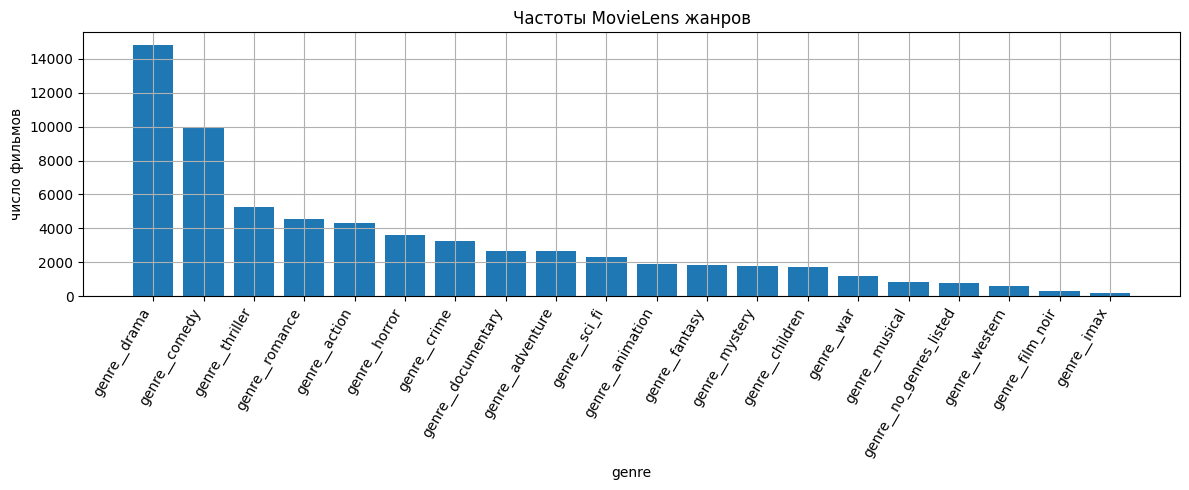

,genre,count
0,genre__drama,14822
1,genre__comedy,9978
2,genre__thriller,5285
3,genre__romance,4532
4,genre__action,4307
5,genre__horror,3579
6,genre__crime,3224
7,genre__documentary,2659
8,genre__adventure,2646
9,genre__sci_fi,2325


In [19]:

if item_features_all is not None:
    genre_cols = [c for c in item_features_all.columns if c.startswith("genre__")]
    if genre_cols:
        genre_freq = item_features_all[genre_cols].sum().sort_values(ascending=False)

        plt.figure(figsize=(12, 5))
        plt.bar(genre_freq.index, genre_freq.values)
        plt.title("Частоты MovieLens жанров")
        plt.xlabel("genre")
        plt.ylabel("число фильмов")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.show()

        display(genre_freq.rename("count").reset_index().rename(columns={"index": "genre"}))

## 16. Частоты IMDb-жанров

Аналогичная проверка для жанров, полученных из IMDb.


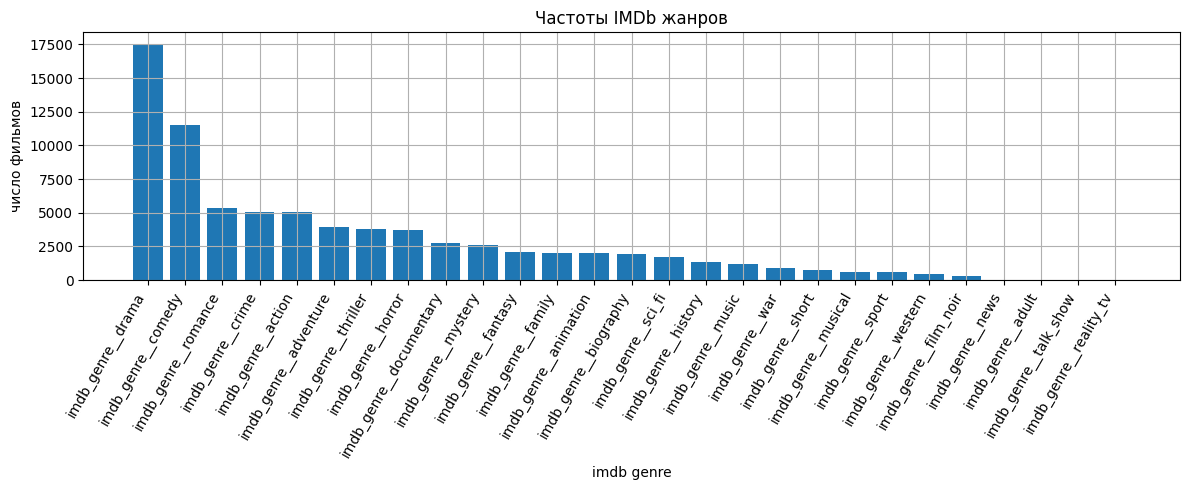

,genre,count
0,imdb_genre__drama,17527.0
1,imdb_genre__comedy,11514.0
2,imdb_genre__romance,5367.0
3,imdb_genre__crime,5078.0
4,imdb_genre__action,5036.0
5,imdb_genre__adventure,3912.0
6,imdb_genre__thriller,3810.0
7,imdb_genre__horror,3743.0
8,imdb_genre__documentary,2763.0
9,imdb_genre__mystery,2580.0


In [20]:

if item_features_all is not None:
    imdb_genre_cols = [c for c in item_features_all.columns if c.startswith("imdb_genre__")]
    if imdb_genre_cols:
        imdb_genre_freq = item_features_all[imdb_genre_cols].sum().sort_values(ascending=False)

        plt.figure(figsize=(12, 5))
        plt.bar(imdb_genre_freq.index, imdb_genre_freq.values)
        plt.title("Частоты IMDb жанров")
        plt.xlabel("imdb genre")
        plt.ylabel("число фильмов")
        plt.xticks(rotation=60, ha="right")
        plt.tight_layout()
        plt.show()

        display(imdb_genre_freq.rename("count").reset_index().rename(columns={"index": "genre"}))

## 17. Основные числовые признаки фильмов

Проверяем распределения числовых признаков: год, длительность, агрегаты по участникам съёмочной группы и другие признаки.


In [21]:

if item_features_all is not None:
    candidate_num_cols = [
        "year",
        "decade",
        "startYear",
        "runtimeMinutes",
        "runtimeMinutes_log1p",
        "n_principals",
        "n_directors",
        "n_writers",
        "n_cast_total",
        "n_actor",
        "n_actress",
        "n_distinct_principal_categories",
        "cast_top50_count",
        "cast_top100_count",
        "cast_top250_count",
        "cast_top500_count",
        "director_top50_count",
        "director_top100_count",
        "director_top250_count",
        "director_top500_count",
        "cast_popularity_max",
        "cast_popularity_mean",
        "cast_popularity_sum",
        "director_popularity_max",
        "director_popularity_mean",
        "director_popularity_sum",
    ]

    num_cols = [c for c in candidate_num_cols if c in item_features_all.columns]
    num_desc = item_features_all[num_cols].describe().T
    display(num_desc)

,count,mean,std,min,25%,50%,75%,max
year,32720.0,1989.084106,105.935692,0.0,1983.000000,2003.000000,2012.00000,2019.00000
decade,32720.0,1984.373047,105.681602,0.0,1980.000000,2000.000000,2010.00000,2010.00000
startYear,32720.0,1989.579346,101.259476,0.0,1983.000000,2003.000000,2012.00000,2021.00000
runtimeMinutes,32720.0,97.303757,29.841333,0.0,88.000000,97.000000,110.00000,776.00000
runtimeMinutes_log1p,32720.0,4.497399,0.574375,0.0,4.488636,4.584968,4.70953,6.65544
n_principals,32720.0,19.292054,4.406037,0.0,18.000000,20.000000,22.00000,57.00000
n_directors,32720.0,1.138722,0.862703,0.0,1.000000,1.000000,1.00000,60.00000
n_writers,32720.0,2.240312,1.746027,0.0,1.000000,2.000000,3.00000,40.00000
n_cast_total,32720.0,9.127048,3.309041,0.0,10.000000,10.000000,10.00000,42.00000
n_actor,32720.0,6.018857,2.745940,0.0,5.000000,6.000000,8.00000,26.00000


## 18. Корреляции числовых item features

Смотрим пары признаков с высокой корреляцией.  
Это не обязательно проблема, но полезно понимать структуру признакового пространства и почистить наиболее скоррелированные признаки.


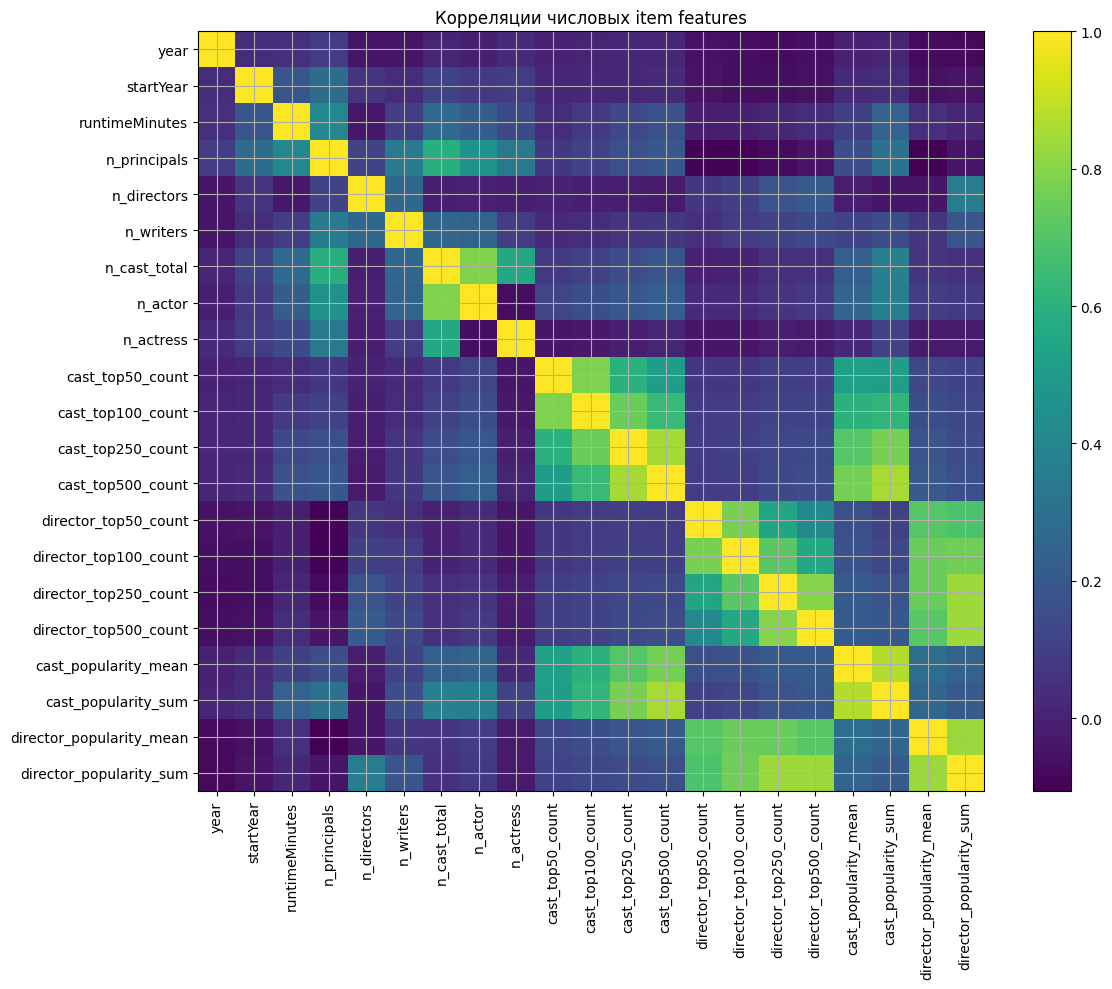

In [22]:

if item_features_all is not None:
    num_cols = [
        c for c in [
            "year",
            "startYear",
            "runtimeMinutes",
            "n_principals",
            "n_directors",
            "n_writers",
            "n_cast_total",
            "n_actor",
            "n_actress",
            "cast_top50_count",
            "cast_top100_count",
            "cast_top250_count",
            "cast_top500_count",
            "director_top50_count",
            "director_top100_count",
            "director_top250_count",
            "director_top500_count",
            "cast_popularity_mean",
            "cast_popularity_sum",
            "director_popularity_mean",
            "director_popularity_sum",
        ]
        if c in item_features_all.columns
    ]

    corr = item_features_all[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 10))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Корреляции числовых item features")
    plt.tight_layout()
    plt.show()

## 19. Сравнение warm train и cold-user support

Сравниваем длины историй в warm train и support-историях cold-пользователей.


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
cold_user_support,15935.0,144.051271,258.179335,1.0,28.0,62.0,152.0,5607.0
warm_train,144009.0,135.924192,245.079568,1.0,26.0,58.0,143.0,21687.0


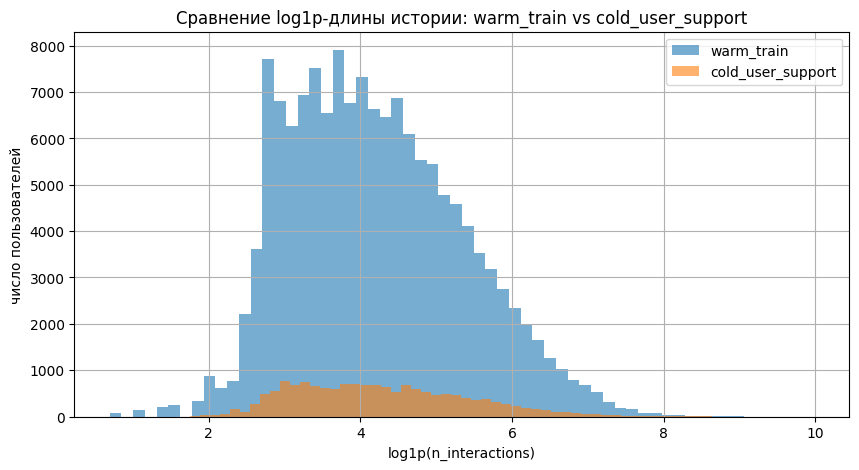

In [23]:

def hist_len(df, name):
    if df is None or "userId" not in df.columns:
        return None
    s = df.groupby("userId").size().rename("n_interactions").reset_index()
    s["split"] = name
    return s

hist_parts = [
    hist_len(train, "warm_train"),
    hist_len(cold_user_support_all if cold_user_support_all is not None else cold_user_support, "cold_user_support"),
]

hist_parts = [x for x in hist_parts if x is not None]
if hist_parts:
    hist_compare = pd.concat(hist_parts, ignore_index=True)
    display(hist_compare.groupby("split")["n_interactions"].describe())

    plt.figure(figsize=(10, 5))
    for split_name in hist_compare["split"].unique():
        vals = hist_compare.loc[hist_compare["split"] == split_name, "n_interactions"].values
        plt.hist(np.log1p(vals), bins=60, alpha=0.6, label=split_name)
    plt.title("Сравнение log1p-длины истории: warm_train vs cold_user_support")
    plt.xlabel("log1p(n_interactions)")
    plt.ylabel("число пользователей")
    plt.legend()
    plt.show()

## 20. Итоговый компактный отчёт

Финальный блок собирает ключевые числа по датасету в одну таблицу.


In [24]:

report = {}

if train is not None:
    report["train_rows"] = len(train)
    report["train_users"] = train["userId"].nunique()
    report["train_items"] = train["movieId"].nunique()
    report["train_rating_mean"] = float(train["rating"].mean())

if warm_val is not None:
    report["warm_val_rows"] = len(warm_val)

if warm_test is not None:
    report["warm_test_rows"] = len(warm_test)

if cold_user_val is not None:
    report["cold_user_val_rows"] = len(cold_user_val)
    report["cold_user_eval_users"] = cold_user_val["userId"].nunique()

if cold_item_val is not None:
    report["cold_item_val_rows"] = len(cold_item_val)
    report["cold_item_eval_items"] = cold_item_val["movieId"].nunique()

if item_features_all is not None:
    report["item_features_all_shape"] = item_features_all.shape

if feature_cols is not None:
    report["n_feature_cols"] = len(feature_cols)

print(json.dumps(report, indent=2, ensure_ascii=False))

{
  "train_rows": 19574307,
  "train_users": 144009,
  "train_items": 31999,
  "train_rating_mean": 3.5480103492736816,
  "warm_val_rows": 604994,
  "warm_test_rows": 987722,
  "cold_user_val_rows": 66243,
  "cold_user_eval_users": 15918,
  "cold_item_val_rows": 35162,
  "cold_item_eval_items": 650,
  "item_features_all_shape": [
    32720,
    172
  ],
  "n_feature_cols": 160
}
